#### Statistical Correlation & Feature Selection


--- Feature Correlation with Readmission_30D ---
Readmission_30D          1.000000
Acuity_Score             0.282744
Comorbidity_Weight       0.116103
Length_of_Stay           0.084551
Is_Chronic               0.059965
Trauma_Level             0.018776
Hospital_FK              0.010179
Discharge_Date_FK        0.006146
Encounter_SK             0.005879
Is_Holiday_Admit         0.004088
Provider_FK              0.003259
Patient_FK               0.002436
Age_at_Encounter         0.002427
Zip_Code_Prefix          0.001503
Total_Charge             0.001407
Total_Procedure_Count    0.001184
Payer_FK                 0.001172
NPI_Number               0.000640
Quarter_Discharge       -0.000031
Experience_Years        -0.000222
is_high_risk_flag       -0.000375
is_transfer             -0.000375
Reimbursement_Rate      -0.000465
Is_In_Network           -0.001278
Is_Holiday_Discharge    -0.001628
Is_Deceased             -0.001723
Date_SK_Discharge       -0.001997
Quarter_Admit           -0.00211

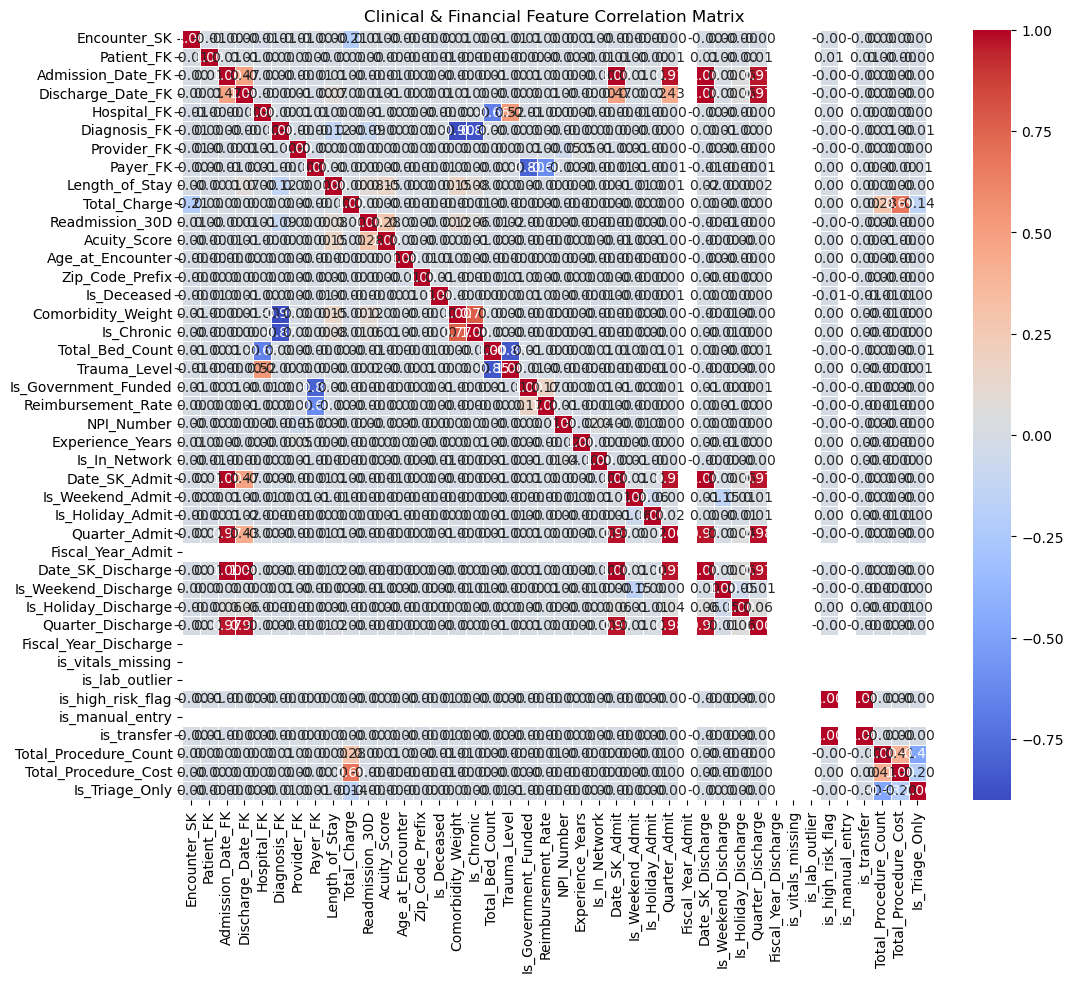

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the base path and load Phase 3
path = r'C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\'
df = pd.read_excel(path + 'Master_EDA_Phase3.xlsx')

# Normalize column names to ensure consistency
df.columns = df.columns.str.strip()

# 2. Filter for Numerical Columns
# This includes the clinical scores, financial metrics, and the triage flag
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# 3. Generate Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Clinical & Financial Feature Correlation Matrix')
plt.savefig(path + 'EDA_Correlation_Matrix.png')

# 4. Feature Selection: Ranking the Predictors
# Extracting the correlation values specifically for the 30-day target
target_corr = corr_matrix['Readmission_30D'].sort_values(ascending=False)

print("\n--- Feature Correlation with Readmission_30D ---")
print(target_corr)

# 5. Final Model-Ready Export
# The dataset is saved as the final source for the Machine Learning phase
df.to_excel(path + 'Master_Data_Final_Model_Ready.xlsx', index=False)

print(f"\nStep 5 Analysis Complete. Final file saved as Master_Data_Final_Model_Ready.xlsx.")

Optimized Correlation Matrix saved as EDA_Correlation_Matrix_Optimized.png


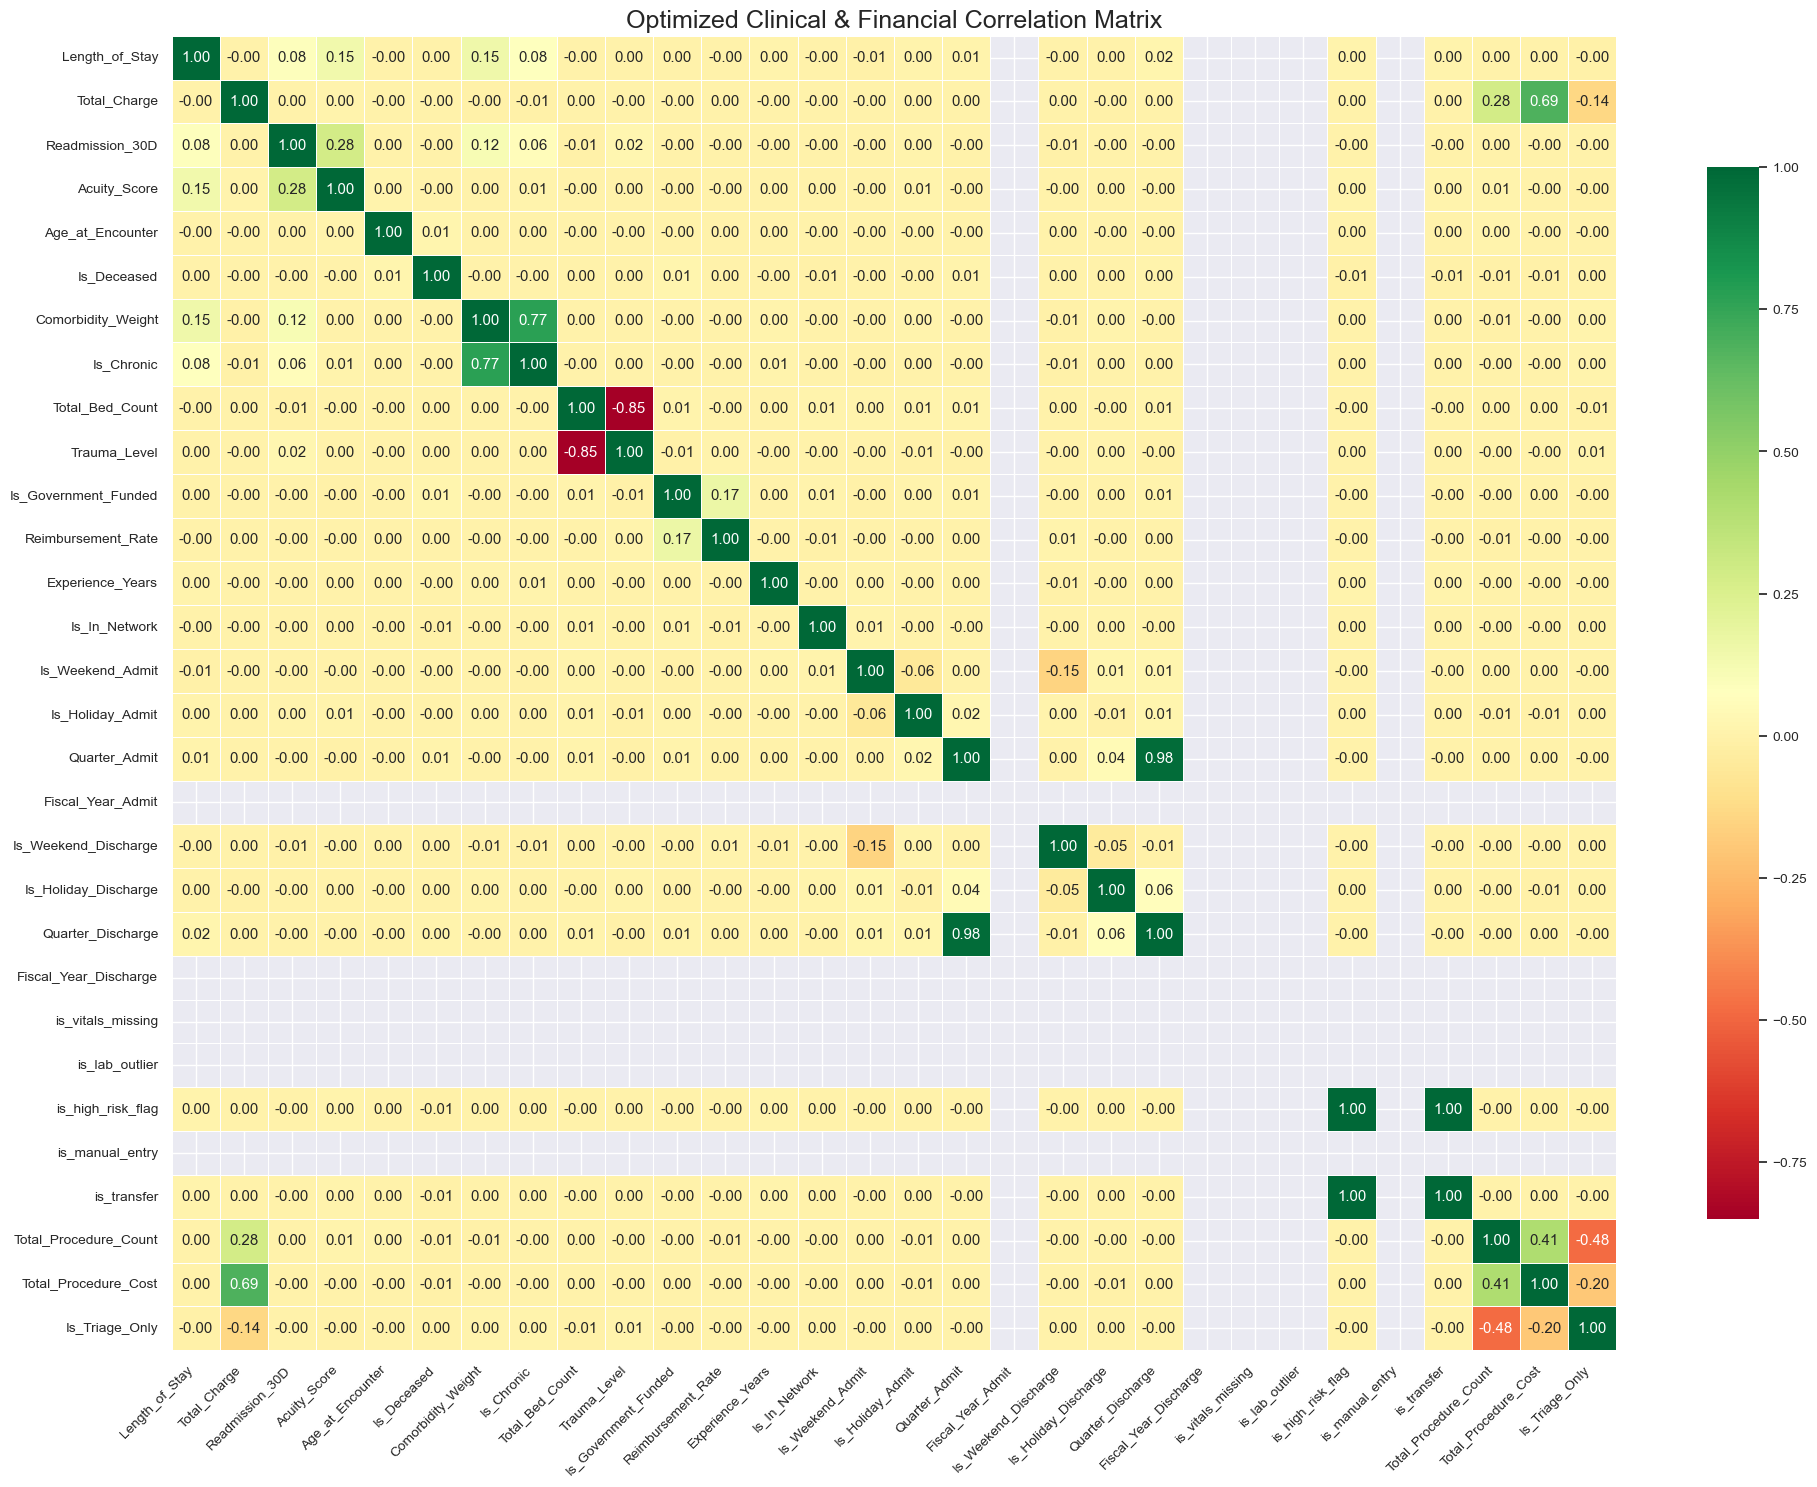

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the base path and load the final model-ready file
path = r'C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\'
df = pd.read_excel(path + 'Master_Data_Final_Model_Ready.xlsx')

# 2. Filter for significant features
# Removing IDs, Keys, and Columns with NaN values to clean the plot
cols_to_drop = [c for c in df.columns if 'SK' in c or 'FK' in c or 'Number' in c or 'Zip' in c]
df_clean = df.drop(columns=cols_to_drop)
df_clean = df_clean.dropna(axis=1, how='all')

# 3. Calculate Correlation
corr_matrix = df_clean.select_dtypes(include=['float64', 'int64']).corr()

# 4. Generate High-Resolution Heatmap
# Increased figsize to 20x15 and adjusted font_scale for readability
plt.figure(figsize=(20, 15))
sns.set(font_scale=0.9)
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdYlGn', 
            fmt=".2f", 
            linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('Optimized Clinical & Financial Correlation Matrix', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# 5. Save the improved image
plt.savefig(path + 'EDA_Correlation_Matrix_Optimized.png', dpi=300)
print("Optimized Correlation Matrix saved as EDA_Correlation_Matrix_Optimized.png")